# **Lab 3: Mitigating Bias Using Fairlearn & Aequitas**

Previously we explored bias metrics and measuring bias in a binary classification machine learning model. In this Lab we will continue working on the same data and ML model, this time using Fairlearn to perform bias-mitigating interventions in three different ways:

*   **Preprocessing interventions:** These algorithms transform the dataset (prior to training a model) in order to mitigate possible unfairness present in the data.
    - Example: One way to think about bias is as correlation between sensitive and non-sensitive features in the dataset. By applying the [CorrelationRemover](https://fairlearn.org/v0.7.0/api_reference/fairlearn.preprocessing.html#fairlearn.preprocessing.CorrelationRemover), these correlations are projected away while details from the original data are retained as much as possible (as measured by least-squares error). The user can control the level of projection via the `alpha` parameter.

*   **Reduction algorithms:** At a high level, the reduction algorithms within Fairlearn enable bias mitigation for machine learning models using user-provided constraints. The two available algorithms are [Exponentiated Gradient](https://fairlearn.org/v0.7.0/api_reference/fairlearn.reductions.html#fairlearn.reductions.ExponentiatedGradient) and [Grid Search](https://fairlearn.org/v0.7.0/api_reference/fairlearn.reductions.html#fairlearn.reductions.GridSearch). The reductions approach seeks to reduce binary classification and regression problems subject to fairness contrains to a sequence of weighted classification problems. As a result, the reduction algorithms in Fairlearn only require a wrapper to access to any “base” learning algorithm. By this we mean that the “base” algorithm only needs to implement `fit` and `predict` methods (like any standard scikit-learn estimator) but it does not need to have any knowledge of the desired fairness constraints or sensitive features.

    From an API perspective this looks as follows in all situations:

  > reduction = Reduction(base_estimator, constraints, **kwargs)  
  > reduction.fit(X_train, y_train, sensitive_features=sensitive_features)  
  > reduction.predict(X_test)  

*   **Postprocessing algorithms:** The postprocessing algorithms transform the *outputs* of a classification or regression model to mitigate bias. For example, the [ThresholdOptimizer](https://fairlearn.org/v0.7.0/api_reference/fairlearn.postprocessing.html#fairlearn.postprocessing.ThresholdOptimizer) takes as input an existing classifier and the sensitive feature, and derives a monotone transformation of the classifier’s prediction to enforce the specified parity constraints.

This Lab is divided into the following parts:

1. Load the data as we did in Lab 2
2. Use preprocessing algorithms to mitigate bias
3. Use reduction algorithms to mitigate bias
4. Use postprocessing algorithms to mitigate bias
5. Compare all of our efforts

In [1]:
%%capture
#@markdown

!pip install fairlearn
!pip install "git+https://github.com/samgalen/folktables.git@archive_url"
!pip install "git+https://github.com/DataResponsibly/fixed_acs_loader.git"

In [2]:
#@markdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as skm
from sklearn.model_selection import cross_val_score
import matplotlib.ticker as ticker
from sklearn.metrics import accuracy_score

from folktables import ACSDataSource, ACSEmployment, ACSIncome, ACSPublicCoverage, ACSTravelTime
from acsloader.data.acs_helper import ACSData

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio, selection_rate
from fairlearn.metrics import false_negative_rate, false_positive_rate
from fairlearn.datasets import fetch_adult
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import ExponentiatedGradient
from fairlearn.reductions import GridSearch
from fairlearn.reductions import DemographicParity, ErrorRate
from fairlearn.postprocessing import ThresholdOptimizer

from IPython.display import clear_output

#1. Load Data, Conduct Exploratory Analysis, and Preprocess Data
Next, we will load the Folktables dataset.  The Folktables dataset is taken from US Census Data and is built to solve a few simple prediction tasks. The sample we pull is data from 2017 in California. The column names are described in the table below. Note that certain categorical variables have been mapped to integer values, which we will keep as-is for the following analyses.


| Column Name | Feature | Description/Notes |
| --- | ----------- | --- |
| PINCP | Total person’s income | (Target) 1 if >= $50k, 0 if less |
| SEX | Sex | (Sensitive Attribute) Male=1, Female=2 |
| RAC1P | Race | (Sensitive Attribute) White=1, Black=2, Other races are between 3 and 9 |
| AGEP | Age | Ranges from 0-99 |
| COW | Class of Worker | Ranges 1-9, see paper for description |
| SCHL | Education Level | Ranges 1-24, see paper for description |
| MAR | Marital Status | Ranges 1-5, see paper for description |
| OCCP | Occupation | Codes taken from Public Use Microdata Sample (PUMS) from the US Census, see paper |
| POBP | Place of Birth | Codes taken from Public Use Microdata Sample (PUMS) from the US Census, see paper |
| RELP | Relationship | Relationship of individual to person who responded to the Census taker. Ranges 0-17, see paper for description |
| WKHP | Hours worked per week | Ranges from 0-99, averaged over previous year |

In [3]:
#@markdown Read in the folktables dataset
full_df, features_df, target_df, groups_df = ACSData().return_acs_data_scenario(scenario="ACSIncome", subsample=70000)

print(full_df.shape)
full_df.head()

data=full_df

(70000, 11)


In [4]:
#@markdown Drop rows with missing values
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGEP    70000 non-null  float64
 1   COW     70000 non-null  float64
 2   SCHL    70000 non-null  float64
 3   MAR     70000 non-null  float64
 4   OCCP    70000 non-null  float64
 5   POBP    70000 non-null  float64
 6   RELP    70000 non-null  float64
 7   WKHP    70000 non-null  float64
 8   SEX     70000 non-null  float64
 9   RAC1P   70000 non-null  float64
 10  PINCP   70000 non-null  float64
dtypes: float64(11)
memory usage: 5.9 MB


In [5]:
#@markdown Change data types of categorical features
numerical_cols = ['AGEP','WKHP']
categorical_cols = ['COW','SCHL','MAR','OCCP','POBP','RELP','RAC1P','SEX']

for col in categorical_cols:
  data[col] = data[col].astype('int')
  data[col] = data[col].astype('str')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGEP    70000 non-null  float64
 1   COW     70000 non-null  object 
 2   SCHL    70000 non-null  object 
 3   MAR     70000 non-null  object 
 4   OCCP    70000 non-null  object 
 5   POBP    70000 non-null  object 
 6   RELP    70000 non-null  object 
 7   WKHP    70000 non-null  float64
 8   SEX     70000 non-null  object 
 9   RAC1P   70000 non-null  object 
 10  PINCP   70000 non-null  float64
dtypes: float64(3), object(8)
memory usage: 5.9+ MB


In [6]:
#@markdown Standardize numerical features
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
data.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,0.692716,2,17,1,100,6,0,0.166795,1,3,0.0
1,0.692716,6,16,3,4510,6,0,0.166795,2,1,0.0
2,0.150900,1,17,1,9640,303,0,0.166795,1,8,1.0
3,-1.542275,1,18,5,3600,6,12,0.012040,2,9,0.0
4,-0.526370,1,20,5,2630,6,13,0.166795,2,8,1.0


In [7]:
#@markdown One-hot encode categorical features
data = pd.get_dummies(data)

#since the sex attribute is already binary we can drop one of the redundant dummy columns
#note: males are now labeled as 1 and females are labeled as 0
data.drop(columns=['SEX_2'], inplace=True)
data.rename(columns={'SEX_1':'SEX'}, inplace=True)

data.head()

,AGEP,WKHP,PINCP,COW_1,COW_2,COW_3,COW_4,COW_5,COW_6,COW_7,...,SEX,RAC1P_1,RAC1P_2,RAC1P_3,RAC1P_4,RAC1P_5,RAC1P_6,RAC1P_7,RAC1P_8,RAC1P_9
0,0.692716,0.166795,0.0,False,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,0.692716,0.166795,0.0,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
2,0.150900,0.166795,1.0,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
3,-1.542275,0.012040,0.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,-0.526370,0.166795,1.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [8]:
#@markdown Split data into training and test sets
target = data['PINCP']
data.drop(columns='PINCP', inplace=True)

#note: here we are setting a value for the random_state (seed) parameter so that the results of this lab will remain consistent
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=4)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (56000, 757)
y_train shape: (56000,)
X_test shape: (14000, 757)
y_test shape: (14000,)


Next, we will replicate our procedure from Lab 2 where we train a classifier and evaluate its accuracy and bias.

In [9]:
#@markdown Implement logistic regression
clf = LogisticRegression()
clf.fit(X_train, y_train)
clf_accuracy = clf.score(X_test, y_test)

clear_output()

print(f'Logistic Regression test accuracy: {clf_accuracy:.4f}')

Logistic Regression test accuracy: 0.8176


In [10]:
#@markdown Evaluate the fairness of the classifier using demographic_parity_difference and demographic_parity_ratio
#note: we are conducting this analysis over the test set

#compute test predictions
y_pred = clf.predict(X_test)

#compute demographic parity difference and demographic parity ratio
demo_parity_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=X_test['SEX'])
demo_parity_ratio = demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['SEX'])

print(f'Demographic parity difference: {demo_parity_diff:.4f}')
print(f'Demographic parity ratio: {demo_parity_ratio:.4f}')

#compute selection rate for males and females
male_selection_rate = selection_rate(y_test[X_test['SEX']==1], y_pred[X_test['SEX']==1])
female_selection_rate = selection_rate(y_test[X_test['SEX']==0], y_pred[X_test['SEX']==0])

print(f'Male selection rate: {male_selection_rate:.4f}')
print(f'Female selection rate: {female_selection_rate:.4f}')

Demographic parity difference: 0.1271
Demographic parity ratio: 0.7167
Male selection rate: 0.4486
Female selection rate: 0.3215


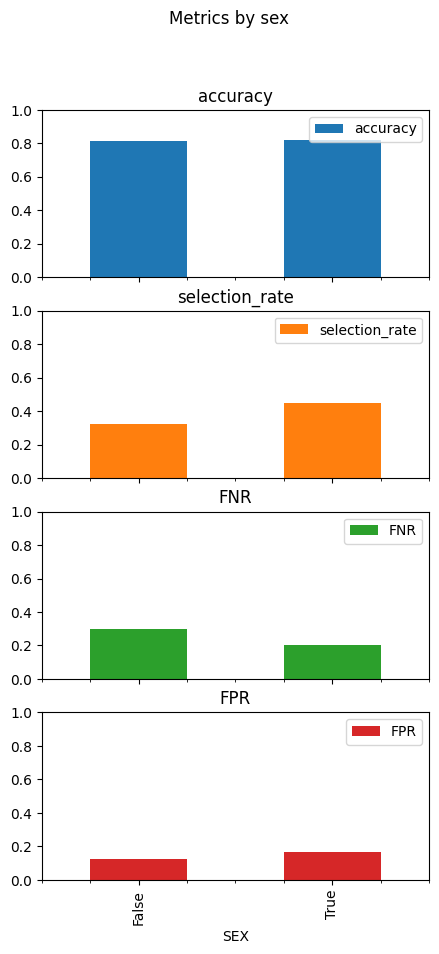

In [11]:
#@markdown Evaluate (plot) the fairness of the classifier using the MetricFrame class

#changing sensitive feature inputs to be 'male' and 'female' instead of 1 and 0
sensitive_feature = X_test['SEX'].replace({0:'female', 1:'male'})

#evaluation metrics
metrics = {'accuracy': skm.accuracy_score,
           'selection_rate': selection_rate,  # i.e., the percentage of the population which have ‘1’ as their predicted label
           'FNR': false_negative_rate,
           'FPR': false_positive_rate
           }

grouped_on_sex = MetricFrame(metrics=metrics,
                             y_true=y_test,
                             y_pred=y_pred,
                             sensitive_features=sensitive_feature)

grouped_on_sex.by_group.plot.bar(
    subplots=True,
    figsize=(5, 10),
    ylim=[0,1],
    title="Metrics by sex",
    )
plt.show()

As before, we see that there are some disparities in the selection rate, FPR, and FNR between males and females. Namely, men have a higher selection rate because the have both a lower false negative rate and higher false positive rate.

#2. Reduction algorithms

Both **GridSearch** and **ExponentialGradient** can be used for binary classification and regression models, supporting the following fairness definitions:

*   **Demographic Parity:** ensures that the selection rate or percentage of samples with label = 1 is equal across all groups. Implicitly this means the percentage with label = 0 is equal as well.

*   **True Positive Rate Parity and False Positive Rate Parity:** ensures that the True Positive Rate (TP / TP + FN) **OR** the False Positive Rate (FP / FP + TN) is equal across all groups. In first case, we only consider samples with $Y = 1$ and ignore the samples with $Y = 0$, and in the second case vice versa.

*   **Equalized Odds:** ensures that both True Positive Rate (TP / TP + FN) **AND** the False Positive Rate (FP / FP + TN) are equal across all groups. The constraints represent the union of constraints for true positive rate and false positive rate. Thus, samples with both $Y = 1$ and $Y = 0$ are considered.

*   **Error Rate Parity:** ensures that the error rates should be the same across all groups. The __utility__ of our classifier on a single sample $X$ is 0 if we predicted the label correctly, and the utility is 1 otherwise. So, a large __total utility__ (i.e. sum of utilities across all test samples) here corresponds to a poor model.

*   **Control Features:** The above metrics (Demographic Parity, True and False Positive Rate Parity, Equalized Odds, and Error Rate Parity) happen to all fit a math definition which lets us call them __Moments__$\text{}^{\dagger}$. These moments all support __Control Features__ when applying their fairness constraints.
  1. Suppose we are designing a classifier to predict if someone will repay a loan. We may want to be fair towards sex. But, we also don't want to lose information about their annual income, so we want to control for their annual income somehow.
  2. We can split all people into groups based on their income level, and require fairness towards sex _within_ each group. We will not require fairness towards sex _between_ different groups.
  3. In this example, income level is a control feature.
  4. Formally, a control feature stratifies the dataset, and applies the fairness constraint within each stratum, but not between strata.
  5. This should be done with caution, since the control features might be correlated with the sensitive features due to historical biases.
  6. In the loan scenario, we might choose to control for income level, on the grounds that higher income individuals are more likely to be able to repay a loan. However, due to historical bias, there is a correlation between the income level of individuals and their race and gender.

$\phantom{}^{[\dagger]}$ _If you're curious, see https://arxiv.org/pdf/1803.02453.pdf for details on why these are called "moments"._

##2.1 GridSearch

Here, we implement the Grid Search intervention on our classifier and examine its effects on bias in our model.  `GridSearch` implements a simplified version of the [exponentiated gradient reduction](https://fairlearn.org/main/api_reference/generated/fairlearn.reductions.ExponentiatedGradient.html) intervention.  It generates a sequence of relabellings and reweightings and trains a predictor for each.  From there, users can select the model that generates the most favorable tradoff between accuracy and fairness for their specific purpose.

**NOTE**: this code will temporarily create several outputs which say `lbfgs failed to converge`. Ingore these messages.

In [12]:
#@title
#first we specificy Demographic Parity as our fairness metric and generate a train a series of predictors
sweep = GridSearch(LogisticRegression(max_iter=100), constraints=DemographicParity())

sweep.fit(X_train, y_train, sensitive_features=X_train['SEX']) # This will take about 2 minutes

#GridSearch created a bunch of different predictors, stored in this list
predictors = sweep.predictors_

#next, we remove predictors which are dominated in the error-disparity space by others from the sweep
errors, disparities = [], []
for m in predictors:
    def classifier(X): return m.predict(X)

    # Load the training and test data into ErrorRate and DemographicParity objects
    error = ErrorRate()
    error.load_data(X_train, y_train, sensitive_features=X_train['SEX'])
    disparity = DemographicParity()
    disparity.load_data(X_train, y_train, sensitive_features=X_train['SEX'])

    # error.gamma(classifier) and disparity.gamma(classifier) returns the actual error rate and statistical disparity
    errors.append(error.gamma(classifier)[0])
    disparities.append(disparity.gamma(classifier).max())


# A Dataframe of all predictors, their errors, and their disparities
all_results = pd.DataFrame({"predictor": predictors, "error": errors, "disparity": disparities})

best_predictors = []

# for each predictor
for row in all_results.itertuples():
    # find the subset of all predictors with disparity <= this predictor's disparity
    # keep only the errors from that subset
    errors_for_lower_or_eq_disparity = all_results["error"][all_results["disparity"] <= row.disparity]
    if row.error <= errors_for_lower_or_eq_disparity.min():
        # If this predictor has better error than all rows better disparity, add it to the list
        best_predictors.append(row.predictor)

clear_output()

In [13]:
#@title
# here we calculate the accuracy and fairness metrics for our dominant models
# define a bunch of lists that will become Pandas dataframe columns
model_num = []
accuracy_gs = []
demo_parity_diff_gs = []
demo_parity_ratio_gs = []
male_selection_rate_gs = []
female_selection_rate_gs = []

# populate the lists
for i in range(len(best_predictors)):
    y_pred = best_predictors[i].predict(X_test)

    model_num.append("dominant_model_{0}".format(i))
    accuracy_gs.append(accuracy_score(y_test,y_pred))
    demo_parity_diff_gs.append(demographic_parity_difference(y_test, y_pred, sensitive_features=X_test['SEX']))
    demo_parity_ratio_gs.append(demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['SEX']))
    male_selection_rate_gs.append(selection_rate(y_test[X_test['SEX']==1], y_pred[X_test['SEX']==1]))
    female_selection_rate_gs.append(selection_rate(y_test[X_test['SEX']==0], y_pred[X_test['SEX']==0]))

# make the lists into a single pandas dataframe
grid_search_results_df = pd.DataFrame()
grid_search_results_df['model'] = model_num
grid_search_results_df['accuracy'] = accuracy_gs
grid_search_results_df['demo_parity_diff'] = demo_parity_diff_gs
grid_search_results_df['demo_parity_ratio'] = demo_parity_ratio_gs
grid_search_results_df['male_selection_rate'] = male_selection_rate_gs
grid_search_results_df['female_selection_rate'] = female_selection_rate_gs

grid_search_results_df

,model,accuracy,demo_parity_diff,demo_parity_ratio,male_selection_rate,female_selection_rate
0,dominant_model_0,0.817571,0.127088,0.716717,0.448625,0.321537
1,dominant_model_1,0.792571,0.108659,0.759445,0.343042,0.451701


#**TODO**: If we decide to prioritize fairness over accuracy in our model, which of these dominant models would you select and why? Recreate the MetricFrame plots used previously for the selected model.

**Note: Results may changes with different runs.**


**Answer:** I will choose dominant_model_1 because it has a lower demo_parity_diff.

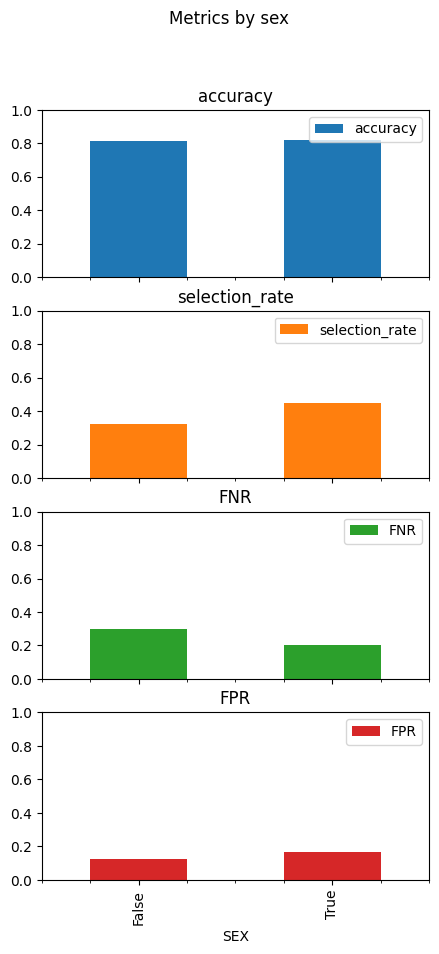

In [14]:
#@markdown Plot the fairness metrics of the selected classifier using the MetricFrame class
selected_model_num = 0
y_pred_gs = best_predictors[selected_model_num].predict(X_test)

grouped_on_sex_grid_search = MetricFrame(metrics=metrics,
                             y_true=y_test,
                             y_pred=y_pred_gs,
                             sensitive_features=sensitive_feature)
#plot the metric values
grouped_on_sex_grid_search.by_group.plot.bar(
    subplots=True,
    figsize=(5, 10),
    ylim=[0,1],
    title="Metrics by sex",
    )
plt.show()

#**TODO**: What does a comparison of these two dominant models tell us about the relationship between accuracy and fairness in our models?

**Answer here:** There is a trade-off between accuracy and fairness. If we want to emphasize fairness, we may have to sacrifice some accuracy.

# 3 Postprocessing algorithms

The logistic regression classifier does not just predict the class of a given input. It can also provide a "confidence" of how likely it thinks the class is postive, as a number between 0 and 1. Often, any confidence above 0.5 is labeled as positive, and any confidence below 0.5 is labeled as negative. In this case, we say that 0.5 is the __confidence threshold__.

To achieve fairness, we will now consider a __postprocessing algorithm__ called [ThresholdOptimizer](https://fairlearn.org/v0.7.0/api_reference/fairlearn.postprocessing.html#fairlearn.postprocessing.ThresholdOptimizer).
The ThresholdOptimizer will use our dataset and the confidence scores of our logistic regression model in order to transform the confidence scores to create a more fair model.

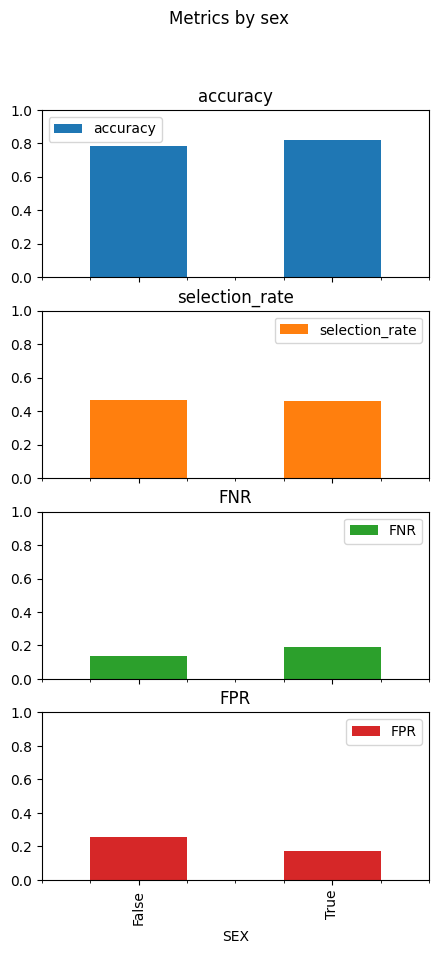

In [15]:
#@markdown

# Train a model on straightforward data
default_model = LogisticRegression(max_iter=500).fit(X_train, y_train)

# Make the post-processed model
postprocessed_model = ThresholdOptimizer(
    estimator=default_model,
    constraints='selection_rate_parity',
    objective='balanced_accuracy_score',
    prefit=True,
    predict_method='predict_proba'
)

# Fit the model to the training data
postprocessed_model.fit(X_train, y_train, sensitive_features=X_train['SEX'])

# Predict on the test data
y_pred_to = postprocessed_model.predict(X_test, sensitive_features=X_test['SEX'])


# Make a metricframe
grouped_on_sex_to = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_to,
    sensitive_features=sensitive_feature
)

# Plot a metricframe grouped by sex
grouped_on_sex_to.by_group.plot.bar(
    subplots=True,
    figsize=(5, 10),
    ylim=[0,1],
    title="Metrics by sex",
    )
plt.show()


In [16]:
#@title
# print the fairness of the unaltered model
print("Naive Model's results:")
print(f'  Demographic parity difference: {demo_parity_diff:.4f}')
print(f'  Demographic parity ratio: {demo_parity_ratio:.4f}')
print(f'  Male selection rate: {male_selection_rate:.4f}')
print(f'  Female selection rate: {female_selection_rate:.4f}')
print()


# evaluate fairness of the classifier with Correlation Remover
print('ThresholdOptimizer results:')

#compute demographic parity difference and demographic parity ratio
X_test_sexes = X_test['SEX'] # store a vector with the sex of everyone in the test data
demo_parity_diff_to = demographic_parity_difference(y_test, y_pred_to, sensitive_features=X_test_sexes)
demo_parity_ratio_to = demographic_parity_ratio(y_test, y_pred_to, sensitive_features=X_test_sexes)

print(f'  Demographic parity difference: {demo_parity_diff_to:.4f}')
print(f'  Demographic parity ratio: {demo_parity_ratio_to:.4f}')

#compute selection rate for males and females
male_selection_rate_to = selection_rate(y_test[X_test_sexes==1], y_pred_to[X_test_sexes==1])
female_selection_rate_to = selection_rate(y_test[X_test_sexes==0], y_pred_to[X_test_sexes==0])

print(f'  Male selection rate: {male_selection_rate_to:.4f}')
print(f'  Female selection rate: {female_selection_rate_to:.4f}')

Naive Model's results:
  Demographic parity difference: 0.1271
  Demographic parity ratio: 0.7167
  Male selection rate: 0.4486
  Female selection rate: 0.3215

ThresholdOptimizer results:
  Demographic parity difference: 0.0075
  Demographic parity ratio: 0.9838
  Male selection rate: 0.4587
  Female selection rate: 0.4663


#**TODO**: Is the ThresholdOptimizer successful at balancing selection rates? Is it fair?

**Answer:** Yes.

Now, we try the same idea, but aiming for `false_negative_rate_parity` instead of `selection_rate_parity`

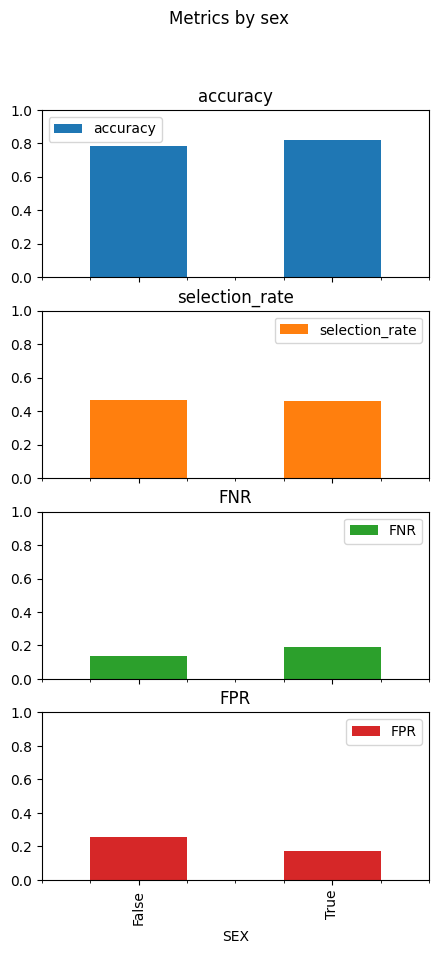

In [17]:
#@title


# Make the post-processed model
postprocessed_model_fnr = ThresholdOptimizer(
    estimator=default_model,
    constraints='false_negative_rate_parity',
    objective='balanced_accuracy_score',
    prefit=True,
    predict_method='predict_proba'
)

# Fit the model to the training data
postprocessed_model_fnr.fit(X_train, y_train, sensitive_features=X_train['SEX'])

# Predict on the test data
y_pred_to_fnr = postprocessed_model_fnr.predict(X_test, sensitive_features=X_test['SEX'])

# Make a metricframe
grouped_on_sex_to_fnr = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_to_fnr,
    sensitive_features=sensitive_feature
)

# Plot a metricframe grouped by sex
grouped_on_sex_to.by_group.plot.bar(
    subplots=True,
    figsize=(5, 10),
    ylim=[0,1],
    title="Metrics by sex",
    )
plt.show()

In [18]:
#@title
# print the fairness of the unaltered model
print("Naive Model's results:")
print(f'  Demographic parity difference: {demo_parity_diff:.4f}')
print(f'  Demographic parity ratio: {demo_parity_ratio:.4f}')
print(f'  Male selection rate: {male_selection_rate:.4f}')
print(f'  Female selection rate: {female_selection_rate:.4f}')
print()


# evaluate fairness of the classifier with Correlation Remover
print('ThresholdOptimizer (for FNR) results:')

#compute demographic parity difference and demographic parity ratio
demo_parity_diff_to_fnr = demographic_parity_difference(y_test, y_pred_to_fnr, sensitive_features=X_test_sexes)
demo_parity_ratio_to_fnr = demographic_parity_ratio(y_test, y_pred_to_fnr, sensitive_features=X_test_sexes)

print(f'  Demographic parity difference: {demo_parity_diff_to_fnr:.4f}')
print(f'  Demographic parity ratio: {demo_parity_ratio_to_fnr:.4f}')

#compute selection rate for males and females
male_selection_rate_to_fnr = selection_rate(y_test[X_test_sexes==1], y_pred_to_fnr[X_test_sexes==1])
female_selection_rate_to_fnr = selection_rate(y_test[X_test_sexes==0], y_pred_to_fnr[X_test_sexes==0])

print(f'  Male selection rate: {male_selection_rate_to_fnr:.4f}')
print(f'  Female selection rate: {female_selection_rate_to_fnr:.4f}')

Naive Model's results:
  Demographic parity difference: 0.1271
  Demographic parity ratio: 0.7167
  Male selection rate: 0.4486
  Female selection rate: 0.3215

ThresholdOptimizer (for FNR) results:
  Demographic parity difference: 0.0750
  Demographic parity ratio: 0.8500
  Male selection rate: 0.5001
  Female selection rate: 0.4251


#**TODO**: Is the ThresholdOptimizer successful at balancing false negative rates? Is it fair?

**Answer**: Approximately yes, but not perfectly. Compare to the naive model and reduces FNR disparity. The ThresholdOptimizer improves fairness slightly, but does not achieve strong demographic parity. So it is not necessary fair.

#**TODO**: Which of the methods we have tried in this lab and lab 2 was the most effective?

I think ThresholdOptimizer is the most effective.

# **4: Aequitas, Intersectionality, and The Fairness Tree**

We will now explore [**Aequitas**](http://www.datasciencepublicpolicy.org/our-work/tools-guides/aequitas/), a different python library for discovering fairness concerns in data. Unlike fairLearn, Aequitas does NOT have any mitigation tools, like the `CorrelationRemover` from last week. It only detects bias. However, it gives great plots out of the box!

We will also explore **Intersectionality**, or how bias for *Black Women* can be significantly worse than bias towards *Black people* and the bias towards *Women*. You will have to write the code to produce these plots.

Lastly, we will explore **The Fairness Tree**, a flow chart created by the [Data Science and Public Policy Lab at CMU](http://www.datasciencepublicpolicy.org/) to help find some fairness measures that can be relevant in your upcomming fair machine learning problems, though you will have to think about the stakeholders on your own still.

---

*Official publication on the Aequitas toolkit: https://arxiv.org/pdf/1811.05577.pdf. The concents of this tutorial are based on the offical Aequitas tutorial, which can be found here: https://dssg.github.io/aequitas/examples/compas_demo.html*

In [19]:
# %%capture
#@markdown
!pip install aequitas
!pip install folktables
!git clone https://github.com/lurosenb/superquail

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.3/932.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.5 MB/s eta 0:00:00
Cloning into 'superquail'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 24 (delta 1), reused 20 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 11.90 KiB | 11.90 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [20]:
#@title
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from folktables import ACSDataSource, ACSEmployment, ACSIncome, ACSPublicCoverage, ACSMobility, ACSTravelTime
from sklearn.preprocessing import StandardScaler
import seaborn as sns

import matplotlib.pyplot as plt
from IPython.display import clear_output

from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
from aequitas.plotting import Plot

#4.1. Load data

We begin by loading our data. Like before, this data is from the American Community Survey (also called "[Folktables](https://github.com/socialfoundations/folktables)"), and contains individual-level data related to income, employment, health, transportation, and housing. The data has millions of records total, and sensitive attributes include race and sex. It includes 5 separate pre-defined prediction tasks. Today, we will be using data from New York in 2018.

For this part of the lab, we will predict if someone is employed (`ESR`). It's less obvious why people care about this task, but for instance consider:
- A dating app is trying to match people up, and not everyone lists their job. Many people prefer to look for an employed partner tho, so wants to secretly infer who is and isn't employed, and use this to match people up.
- This dating app does not want to label people as employed based on their race and sex.

For simplicity, we will also aggregate `RAC1P` down from 8 categories to just 4: people who are only White, only Black, only Asian, and everyone else.

---

**Age:** This dataset will only have people between the ages of 16 and 90.


**Race versus Ethnicity**: in Folktables, ethnicity is a seperate feature from race. So looking at *only the race feature* might hide important traits about people (for example, dataset may identify someone as `race=White` and `ethnicity=Latinx/Hispanic`). Today, we will only use the race feature (`RAC1P`), and we will not use ethnicity (`HISP`). So, this lab is for education purposes, and does not fully illustrate the issues of intersectionality.

For more information about the Folktables features, see page 31 here: https://eaamo2021.eaamo.org/accepted/acceptednonarchival/EAMO21_paper_16.pdf

In [21]:
#@markdown Import Data. The code is slightly different from before since we are picking data from NY specifically.
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["NY"], download=True)


In [22]:
#@title
features, labels, group = ACSEmployment.df_to_numpy(acs_data)
feature_names = ACSEmployment.features
data = pd.DataFrame(features, columns = feature_names)
data.head()

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RAC1P
0,26.0,21.0,5.0,17.0,2.0,0.0,5.0,1.0,4.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0
1,21.0,20.0,5.0,17.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0
2,18.0,16.0,5.0,17.0,2.0,0.0,2.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,8.0
3,85.0,16.0,2.0,16.0,1.0,0.0,1.0,1.0,4.0,4.0,1.0,1.0,2.0,1.0,2.0,1.0
4,19.0,19.0,5.0,17.0,2.0,0.0,1.0,1.0,4.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0


In [23]:
#@markdown Drop rows with missing values
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196967 entries, 0 to 196966
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   AGEP      196967 non-null  float64
 1   SCHL      196967 non-null  float64
 2   MAR       196967 non-null  float64
 3   RELP      196967 non-null  float64
 4   DIS       196967 non-null  float64
 5   ESP       196967 non-null  float64
 6   CIT       196967 non-null  float64
 7   MIG       196967 non-null  float64
 8   MIL       196967 non-null  float64
 9   ANC       196967 non-null  float64
 10  NATIVITY  196967 non-null  float64
 11  DEAR      196967 non-null  float64
 12  DEYE      196967 non-null  float64
 13  DREM      196967 non-null  float64
 14  SEX       196967 non-null  float64
 15  RAC1P     196967 non-null  float64
dtypes: float64(16)
memory usage: 24.0 MB


In [24]:
#@markdown We aggregate race to four groups and make text labels for race and sex.

# Meaning of the aggregated race categories
race_agg_names = {1: 'White',
                  2: 'Black',
                  3: 'Asian',
                  4: 'Other'}

# Meaning of the sex categories
sex_names = {1: 'Male',
             2: 'Female'}

# Aggregating race, mapping from the FolkTables' definition of RAC1P to our
# definition in race_agg_names
RAC1P_mapper = {1:1,
                2:2,
                3:4,
                4:4,
                5:4,
                6:3,
                7:4,
                8:4,
                9:4}

data['RACE_AGG'] = data['RAC1P'].map(RAC1P_mapper)
data['race_name'] = data['RACE_AGG'].map(race_agg_names)
data['sex_name'] = data['SEX'].map(sex_names)

data.drop(columns=['RAC1P'], inplace=True)

data.head()



,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RACE_AGG,race_name,sex_name
0,26.0,21.0,5.0,17.0,2.0,0.0,5.0,1.0,4.0,1.0,2.0,2.0,2.0,2.0,2.0,1,White,Female
1,21.0,20.0,5.0,17.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,1.0,1,White,Male
2,18.0,16.0,5.0,17.0,2.0,0.0,2.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,4,Other,Female
3,85.0,16.0,2.0,16.0,1.0,0.0,1.0,1.0,4.0,4.0,1.0,1.0,2.0,1.0,2.0,1,White,Female
4,19.0,19.0,5.0,17.0,2.0,0.0,1.0,1.0,4.0,2.0,1.0,2.0,2.0,2.0,2.0,1,White,Female


In [25]:
#@markdown Change data types of categorical features
numerical_cols = ['AGEP']
categorical_cols = ['SCHL','MAR','RELP','DIS','ESP','CIT','MIG','MIL','ANC','NATIVITY','DEAR','DEYE','DREM','SEX','RACE_AGG']

for col in categorical_cols:
  data[col] = data[col].astype('int')
  data[col] = data[col].astype('str')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196967 entries, 0 to 196966
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AGEP       196967 non-null  float64
 1   SCHL       196967 non-null  object 
 2   MAR        196967 non-null  object 
 3   RELP       196967 non-null  object 
 4   DIS        196967 non-null  object 
 5   ESP        196967 non-null  object 
 6   CIT        196967 non-null  object 
 7   MIG        196967 non-null  object 
 8   MIL        196967 non-null  object 
 9   ANC        196967 non-null  object 
 10  NATIVITY   196967 non-null  object 
 11  DEAR       196967 non-null  object 
 12  DEYE       196967 non-null  object 
 13  DREM       196967 non-null  object 
 14  SEX        196967 non-null  object 
 15  RACE_AGG   196967 non-null  object 
 16  race_name  196967 non-null  object 
 17  sex_name   196967 non-null  object 
dtypes: float64(1), object(17)
memory usage: 27.0+ MB


In [26]:
#@markdown Standardize numerical features
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
data.head()

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RACE_AGG,race_name,sex_name
0,-0.672132,21,5,17,2,0,5,1,4,1,2,2,2,2,2,1,White,Female
1,-0.884412,20,5,17,2,0,1,3,4,1,1,2,2,2,1,1,White,Male
2,-1.011780,16,5,17,2,0,2,3,4,1,1,2,2,2,2,4,Other,Female
3,1.832769,16,2,16,1,0,1,1,4,4,1,1,2,1,2,1,White,Female
4,-0.969324,19,5,17,2,0,1,1,4,2,1,2,2,2,2,1,White,Female


In [27]:
#@markdown One-hot encode categorical features

# Columns that are categorical and that the blind logistic regression algorithm
# is be allowed to predict with should be one hot encoded
one_hot_encode_cols = ['SCHL','MAR','RELP','DIS','ESP','CIT','MIG','MIL','ANC','NATIVITY','DEAR','DEYE','DREM']

data = pd.get_dummies(data, columns=one_hot_encode_cols)

data.head()

,AGEP,SEX,RACE_AGG,race_name,sex_name,SCHL_0,SCHL_1,SCHL_10,SCHL_11,SCHL_12,...,ANC_4,NATIVITY_1,NATIVITY_2,DEAR_1,DEAR_2,DEYE_1,DEYE_2,DREM_0,DREM_1,DREM_2
0,-0.672132,2,1,White,Female,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,True
1,-0.884412,1,1,White,Male,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
2,-1.011780,2,4,Other,Female,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
3,1.832769,2,1,White,Female,False,False,False,False,False,...,True,True,False,True,False,False,True,False,True,False
4,-0.969324,2,1,White,Female,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True


#**TODO**: Write code to create a new column in `data` called `race_sex_name` which concatenates the `race_name` and `sex_name` columns with an underscore, so it has entries like `Black_Female` or `Other_Male`.


In [28]:
#@title
## TODO: WRITE CODE HERE
data["race_sex_name"] = data.apply(lambda row: row["race_name"]+"_"+row["sex_name"], axis=1)

In [29]:
#@title
#note: here we are setting a value for the random_state (seed) parameter so that the results of this lab will remain consistent
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=4)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (157573, 92)
y_train shape: (157573,)
X_test shape: (39394, 92)
y_test shape: (39394,)


## Train Logistic Regression

We start again by training a straightforward Logistic Regression model on the data. We make the model blind to sex and race, but that's the only mitigation we are using.

**Note:** If you have not finished TODO 1, then remove `race_sex_name` from `drop_cols`.

In [30]:
#@markdown Implement logistic regression

# Remove sex and race
drop_cols = ['SEX', 'RACE_AGG', 'sex_name', 'race_name', 'race_sex_name']
X_train_blind = X_train.drop(columns=drop_cols)
X_test_blind = X_test.drop(columns=drop_cols)

clf = LogisticRegression()
clf.fit(X_train_blind, y_train)
clf_accuracy = clf.score(X_test_blind, y_test)

clear_output()

print(f'Logistic Regression test accuracy: {clf_accuracy:.4f}')

Logistic Regression test accuracy: 0.7972


#4.2. Using Aequitas

## Preparing for Aequitas

Aequitas is picky about the names of columns given to it. We have to provide the following columns:
1. `score` is the prediction made by our model
1. `label_value` is the ground-truth label
1. The only other columns we will keep will be our sensitive attribute labels

**Note:** Keep in mind, a label of 1 means Employed and 0 means Unemployed


In [31]:
#@title
# Compute test predictions
y_pred = clf.predict(X_test_blind)

# Build the of information to pass to Aequitas
pred_data = X_test.filter(items=["race_name","sex_name","race_sex_name"])
pred_data['score'] = y_pred
pred_data['label_value'] = y_test

# Score and label_value are boolean by default, and we need them to be int
pred_data['score'] = pred_data['score'].astype('int')
pred_data['label_value'] = pred_data['label_value'].astype('int')
pred_data = pred_data.rename(columns={'race_name': 'race', 'sex_name': 'sex', 'race_sex_name': 'race_sex'})
# print(df.shape)
pred_data.head()

,race,sex,race_sex,score,label_value
81991,Other,Male,Other_Male,0,0
152046,White,Female,White_Female,0,0
15416,Black,Male,Black_Male,1,1
100832,White,Male,White_Male,0,1
162810,White,Male,White_Male,0,0


## Getting started

Much of the content of this tutorial is based off the Aequitas tutorial found at https://dssg.github.io/aequitas/examples/compas_demo.html.

In [32]:
#@markdown Set the color palette; very optional
aq_palette = sns.diverging_palette(225, 35, n=2)

Broken down by race and sex, we first look at how often, people are employed

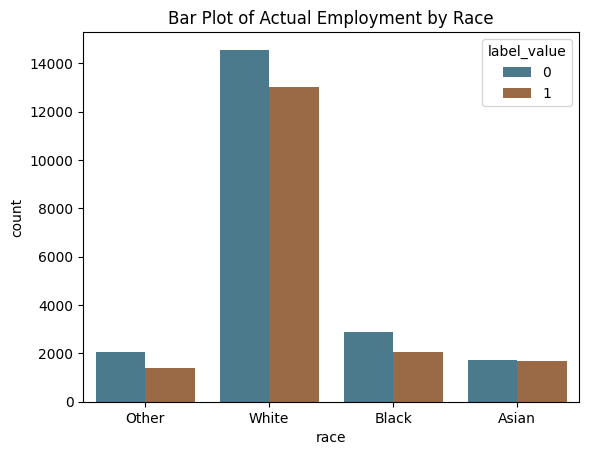

In [33]:
#@title
label_by_race = sns.countplot(x="race", hue="label_value", data=pred_data, palette=aq_palette)
plt.title("Bar Plot of Actual Employment by Race");

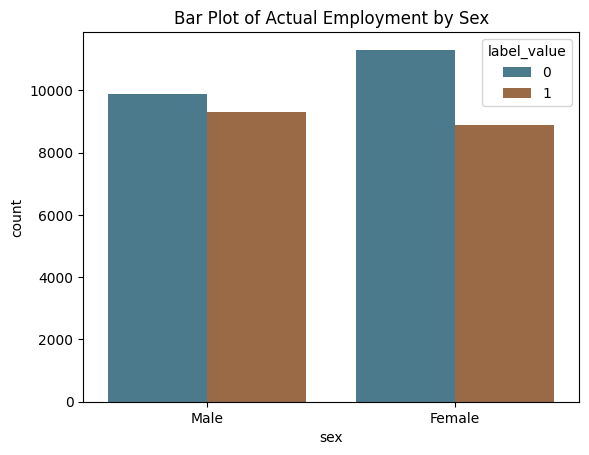

In [34]:
#@title
label_by_sex = sns.countplot(x="sex", hue="label_value", data=pred_data, palette=aq_palette)
plt.title("Bar Plot of Actual Employment by Sex");

We start by plotting the predicted labels across race and sex. These already will show us where our models adds some bias.

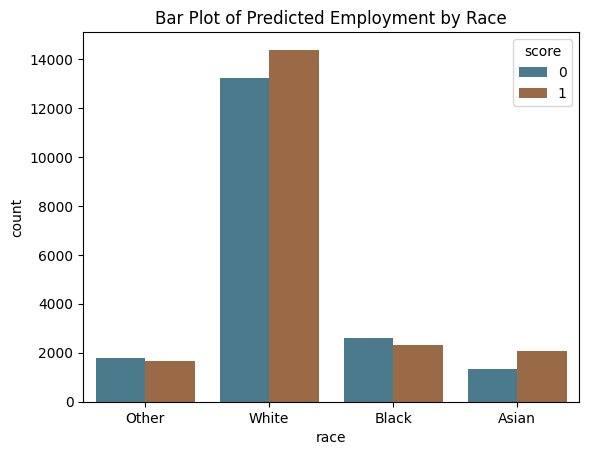

In [35]:
#@markdown Inspect outcome by race

score_race = sns.countplot(x="race", hue="score", data=pred_data, palette=aq_palette)
plt.title("Bar Plot of Predicted Employment by Race");

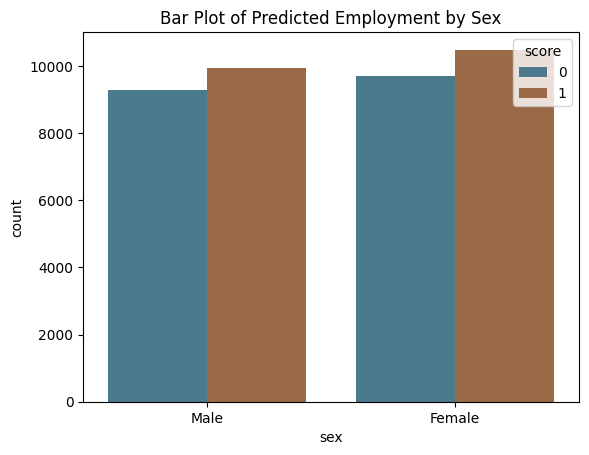

In [36]:
#@title
score_sex = sns.countplot(x="sex", hue="score", data=pred_data, palette=aq_palette)
plt.title("Bar Plot of Predicted Employment by Sex");

#**TODO**: Interpret these plots. By race, which population are majority unemployed, but when predicted as majority employed? For sex, notice both men and women flip from majority unemployed to majority employed. What does this imply about our classifier across the board?

<!-- By race, White and Asian flip. By sex, both men and women flip, which tells us that the classifier overestimates too many people as high-income across the board. -->

**Answer**: White people are majority unemployed, but are predicted as majority employed. The
 classifiers is biased toward predicting the employed class for most populations.

#**TODO:** Write some code to compare actual and predicted employment rates by all intersections of race and sex.

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Other_Male'),
  Text(1, 0, 'White_Female'),
  Text(2, 0, 'Black_Male'),
  Text(3, 0, 'White_Male'),
  Text(4, 0, 'Other_Female'),
  Text(5, 0, 'Asian_Male'),
  Text(6, 0, 'Black_Female'),
  Text(7, 0, 'Asian_Female')])

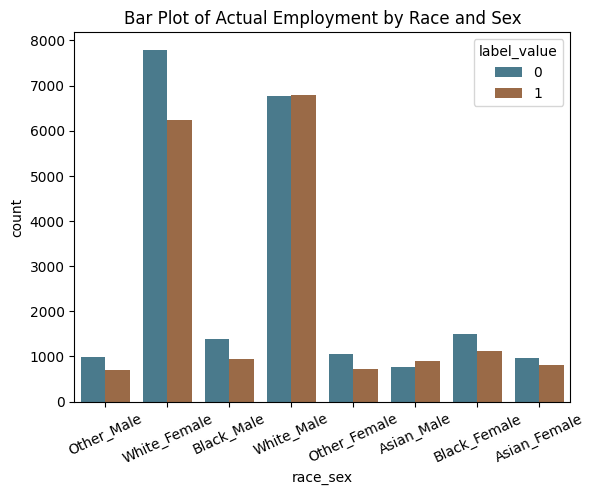

In [37]:
#@title
# WRITE YOUR CODE HERE FOR ACTUAL EMPLOYMENT
# consider using plt.xticks(rotation = 25) to make the x-axis lables more legible
label_by_race_sex = sns.countplot(x="race_sex", hue = "label_value", data = pred_data, palette = aq_palette)
plt.title("Bar Plot of Actual Employment by Race and Sex")
plt.xticks(rotation = 25)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Other_Male'),
  Text(1, 0, 'White_Female'),
  Text(2, 0, 'Black_Male'),
  Text(3, 0, 'White_Male'),
  Text(4, 0, 'Other_Female'),
  Text(5, 0, 'Asian_Male'),
  Text(6, 0, 'Black_Female'),
  Text(7, 0, 'Asian_Female')])

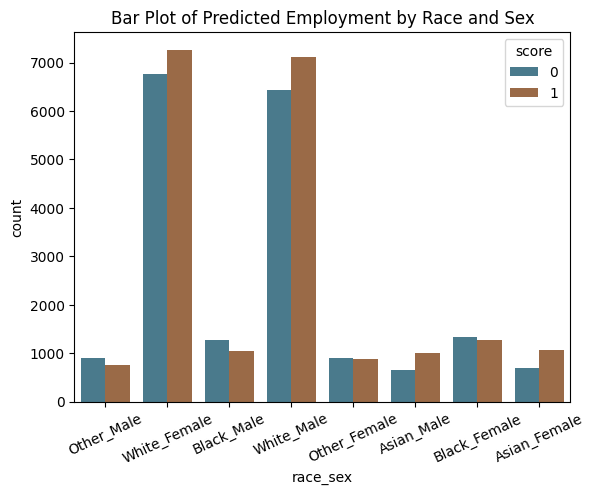

In [38]:
#@title
# WRITE YOUR CODE HERE FOR PREDICTED EMPLOYMENT
score_race_sex = sns.countplot(x = "race_sex", hue = "score", data = pred_data, palette = aq_palette)
plt.title("Bar Plot of Predicted Employment by Race and Sex")
plt.xticks(rotation = 25)

#**TODO:** Note that most white people are unemployed and most men are unemployed, but most white men are employed. How is this possible?

<!-- It's only possible for white men to be majority employed because non-white men and white non-men have much lower employment rates. -->

**Answer**: This contradiction is explained by Simpson's paradox. Many white women are unemployed, but are predicted as employed. When we consider only race or sex, the unemploted condition of white women is masked.

## Using Aequitas

Practitioners need a way to decide if thse patterns reflect bias or not. The fact that there are many ways to detect bias makes this harder. To help with this, Aequitas provides a tool that reports a lot metrics all at once.


In [39]:
#@title
g = Group()
xtab, _ = g.get_crosstabs(pred_data)

In [40]:
#@markdown Get a sense of the predicted positives/negatives and confusion matrix
absolute_metrics = g.list_absolute_metrics(xtab)
xtab[[col for col in xtab.columns if col not in absolute_metrics]]

,model_id,score_threshold,k,attribute_name,attribute_value,pp,pn,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities
0,0,binary 0/1,20417,race,Asian,2070,1347,581,205,1142,1489,1694,1723,3417,39394
1,0,binary 0/1,20417,race,Black,2326,2615,647,384,2231,1679,2063,2878,4941,39394
2,0,binary 0/1,20417,race,Other,1645,1806,464,231,1575,1181,1412,2039,3451,39394
3,0,binary 0/1,20417,race,White,14376,13209,3413,2065,11144,10963,13028,14557,27585,39394
4,0,binary 0/1,20417,sex,Female,10486,9703,3011,1406,8297,7475,8881,11308,20189,39394
5,0,binary 0/1,20417,sex,Male,9931,9274,2094,1479,7795,7837,9316,9889,19205,39394
6,0,binary 0/1,20417,race_sex,Asian_Female,1069,698,376,108,590,693,801,966,1767,39394
7,0,binary 0/1,20417,race_sex,Asian_Male,1001,649,205,97,552,796,893,757,1650,39394
8,0,binary 0/1,20417,race_sex,Black_Female,1271,1334,362,208,1126,909,1117,1488,2605,39394
9,0,binary 0/1,20417,race_sex,Black_Male,1055,1281,285,176,1105,770,946,1390,2336,39394


Aequitas uses some names and acronyms unlike what we have used in class:
- `precision` is PPV
- `ppr` $ = \frac{\text{PP}_G}{P}$ where $P$ is the total number of people predicted positive across all groups, and $\text{PP}_G$ is the number of people in group $G$ predicted positive.
- `pprev` is the Selection Rate
- `prev` is the Prevalence

In [41]:
#@markdown View calculated "absolute metrics" (like false positive rates) for each group
xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,race,Asian,0.77,0.88,0.66,0.15,0.28,0.34,0.12,0.85,0.72,0.10,0.61,0.50
1,race,Black,0.79,0.81,0.78,0.15,0.28,0.22,0.19,0.85,0.72,0.11,0.47,0.42
2,race,Other,0.80,0.84,0.77,0.13,0.28,0.23,0.16,0.87,0.72,0.08,0.48,0.41
3,race,White,0.80,0.84,0.77,0.16,0.24,0.23,0.16,0.84,0.76,0.70,0.52,0.47
4,sex,Female,0.78,0.84,0.73,0.14,0.29,0.27,0.16,0.86,0.71,0.51,0.52,0.44
5,sex,Male,0.81,0.84,0.79,0.16,0.21,0.21,0.16,0.84,0.79,0.49,0.52,0.49
6,race_sex,Asian_Female,0.73,0.87,0.61,0.15,0.35,0.39,0.13,0.85,0.65,0.05,0.60,0.45
7,race_sex,Asian_Male,0.82,0.89,0.73,0.15,0.20,0.27,0.11,0.85,0.80,0.05,0.61,0.54
8,race_sex,Black_Female,0.78,0.81,0.76,0.16,0.28,0.24,0.19,0.84,0.72,0.06,0.49,0.43
9,race_sex,Black_Male,0.80,0.81,0.79,0.14,0.27,0.21,0.19,0.86,0.73,0.05,0.45,0.40


## How do we understand biases in our model?

One of the major contributions of the Aequitas toolkit and enviornment is the `Fairness Tree`.

While a lot of bias metrics and fairness definitions have been proposed, there is no consensus on which definitions and metrics should be used in practice to evaluate and audit these systems. To help with this, the authors of Aequitas also created a guide for understanding when and what metrics might apply in a given situation, called the `Fairness Tree`. It can be found here: http://www.datasciencepublicpolicy.org/our-work/tools-guides/aequitas/



## What is the scenario of our data?

In order to understand what metric (or metrics) we care about for the Folktables employment prediction, we need to know the full context of use, which isn't available. We will have to make one up:
- Suppose the IRS is deciding who to audit. The training data for this tool was authentic random census data, but the test data entirely describes people who listed themselves as unemployed on their tax forms. People predicted to be employed are more likely to get audited.

Ideally, these audits should be distributed evenly across groups and not target one race in particular. These audits can be though of as a *punitive* intervention, because they may result in penalties, fines, or even jail time.

We could argue in favor of several different fairness metrics that are appropiate for this case: *Demographic Parity*, *False Discovery Rate Parity*, and *False Positive Rate Parity*. In this lab, we will use consider the last one (*FPR Parity*).

In [42]:
#@markdown Write down the confusion matrix data again

xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,race,Asian,0.77,0.88,0.66,0.15,0.28,0.34,0.12,0.85,0.72,0.10,0.61,0.50
1,race,Black,0.79,0.81,0.78,0.15,0.28,0.22,0.19,0.85,0.72,0.11,0.47,0.42
2,race,Other,0.80,0.84,0.77,0.13,0.28,0.23,0.16,0.87,0.72,0.08,0.48,0.41
3,race,White,0.80,0.84,0.77,0.16,0.24,0.23,0.16,0.84,0.76,0.70,0.52,0.47
4,sex,Female,0.78,0.84,0.73,0.14,0.29,0.27,0.16,0.86,0.71,0.51,0.52,0.44
5,sex,Male,0.81,0.84,0.79,0.16,0.21,0.21,0.16,0.84,0.79,0.49,0.52,0.49
6,race_sex,Asian_Female,0.73,0.87,0.61,0.15,0.35,0.39,0.13,0.85,0.65,0.05,0.60,0.45
7,race_sex,Asian_Male,0.82,0.89,0.73,0.15,0.20,0.27,0.11,0.85,0.80,0.05,0.61,0.54
8,race_sex,Black_Female,0.78,0.81,0.76,0.16,0.28,0.24,0.19,0.84,0.72,0.06,0.49,0.43
9,race_sex,Black_Male,0.80,0.81,0.79,0.14,0.27,0.21,0.19,0.86,0.73,0.05,0.45,0.40


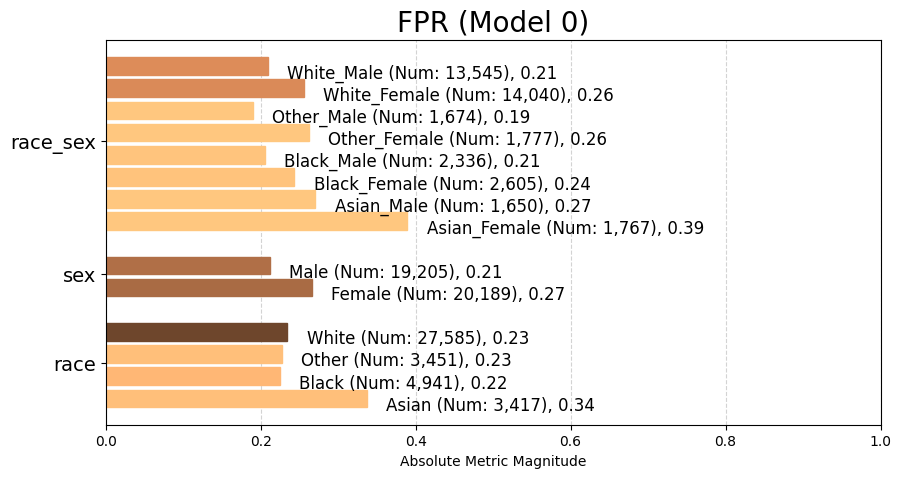

In [43]:
#@markdown Plot the FPR within each group. The darker a bar is, the more people belong to that group.

aqp = Plot()
fnr = aqp.plot_group_metric(xtab, 'fpr')

# Note: if you have small group sizes, you can use the 'min_group_size' parameter:
# fnr = aqp.plot_group_metric(xtab, 'fnr', min_group_size=0.05)


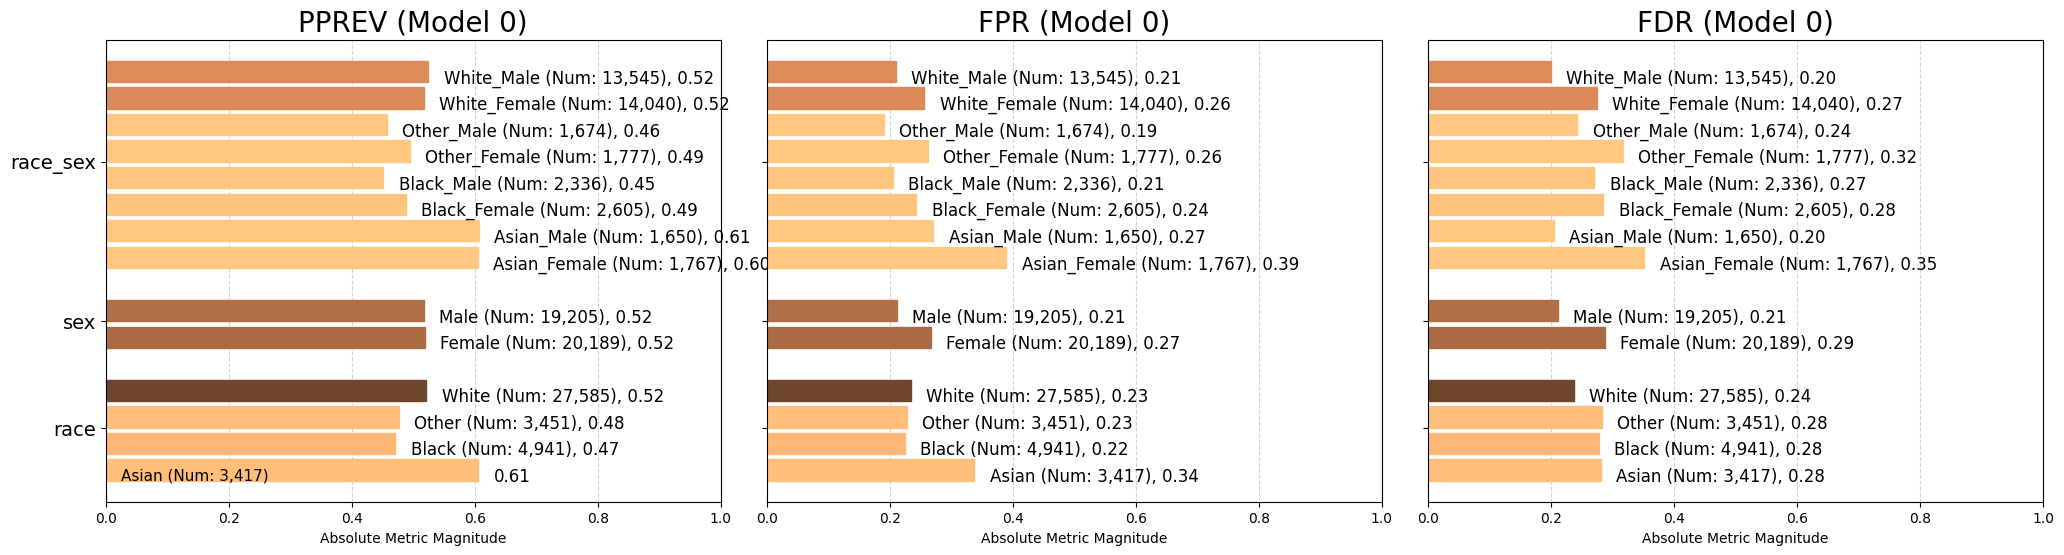

<Figure size 640x480 with 0 Axes>

In [44]:
#@markdown We can look at all three metrics we discussed: Demographic Parity (pprev/selection rate), FDR, and FPR
p = aqp.plot_group_metric_all(xtab, metrics=['pprev','fpr','fdr'], ncols=3)

#**TODO:** Looking at the plot FPR here, we see that Asian women are the most discriminated against group by this model. Now look back at the bar plots  comparing actual and predicted employment rates by all intersections of race and sex. Based on those bar plots, would you describe this bias against women as _Pre-Existing_ or _Technical_?

<!-- It's likely technical. The original data didn't show such a bias against women, but the predictions do, so the bias could likely be mitigate by just making the algorithm fit the given data more closely. -->

**Answer:** Technical

#**TODO:** What do we learn about the FPR on Asian men and Asian women that we cannot figure out by just looking at the FPR across race and gender individually?

<!-- Okay there's probably a bunch of good answers. But I'm thinking of the fact that Asian women really have it the worst. Note both the high FPR of Asians in general, and the not-that-different FPRs of men and women. This makes the gap between Asian men and Asian women relatively surprising.  -->

**Answer:** Asian women has a much higher FPR than Asian men, while Asian men's FPR rate is just a little bit higher than average men. The high FPR for Asians is not uniform across the group but is disproportionately borne by Asian women.

# BONUS:

## Measuring bias with disparity

Typically, error-based metrics judge the fairness of a predictor by considering the *imbalance* between group-specific metrics. We can calculate imbalance as a difference --- mean, squared, absolute, etc. --- or as a **disparity** --- the ratio of a metric of one group, $g_j$, to that of a *reference group*, $g_{ref}$, usually chosen as the majority group:

$disparity_{g_j} = \frac{metric_{g_j}}{metric_{g_{ref}}}$

Generally, we require as a rule-of-thumb that $ 0.8 \leq disparity \leq 1.2$ (i.e. the metrics are within approx. 20% of each other).

Disparity ratios have nice properties. For example, they are robust to small real values. Consider a model that has $fpr_1 = 0.002$ for one group and $fpr_2 = 0.04$ for the other. These values would satisfy a seemingly strict fairness constraint where $|fpr_1 - fpr_2| <= 0.05$, but this is likely not desirable to practitioners. Instead, using disparity ratios, this scenario would be considered unfair since $0.8 \nleq \frac{fpr_1}{fpr_2} \leq 1.2$.

In [ ]:
#@title
b = Bias()
bdf = b.get_disparity_predefined_groups(xtab, original_df=pred_data, ref_groups_dict={'race':'White', 'sex':'Male', 'race_sex': 'White_Male'}, alpha=0.05, mask_significance=True)

## Look for disparity values outside of the bounds 0.8 <= disparity <= 1.2

In [ ]:
#@title
calculated_disparities = b.list_disparities(bdf)
bdf[['attribute_name', 'attribute_value'] +  ['fpr_disparity', 'pprev_disparity', 'fdr_disparity']]

,attribute_name,attribute_value,fpr_disparity,pprev_disparity,fdr_disparity
0,race,Asian,1.438224,1.162413,1.182245
1,race,Black,0.958846,0.903295,1.171646
2,race,Other,0.970591,0.914652,1.188102
3,race,White,1.000000,1.000000,1.000000
4,sex,Female,1.257479,1.004422,1.361812
5,sex,Male,1.000000,1.000000,1.000000
6,race_sex,Asian_Female,1.856410,1.152688,1.763366
7,race_sex,Asian_Male,1.291579,1.155901,1.026720
8,race_sex,Black_Female,1.160296,0.929626,1.427892
9,race_sex,Black_Male,0.977897,0.860498,1.354331


Notice The FPR disparity for race="Asian" is 1.44. That means that Asian folks in the dataset have an FPR 1.44x that of White folks.

We can also look at mosaic plots of the disparity. In these plots, the size of each block corresponds to the relative size of the population.

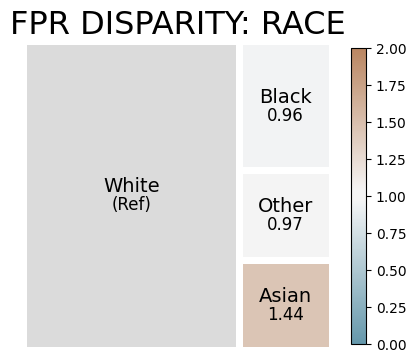

In [ ]:
#@title
aqp.plot_disparity(bdf, group_metric='fpr_disparity', attribute_name='race')

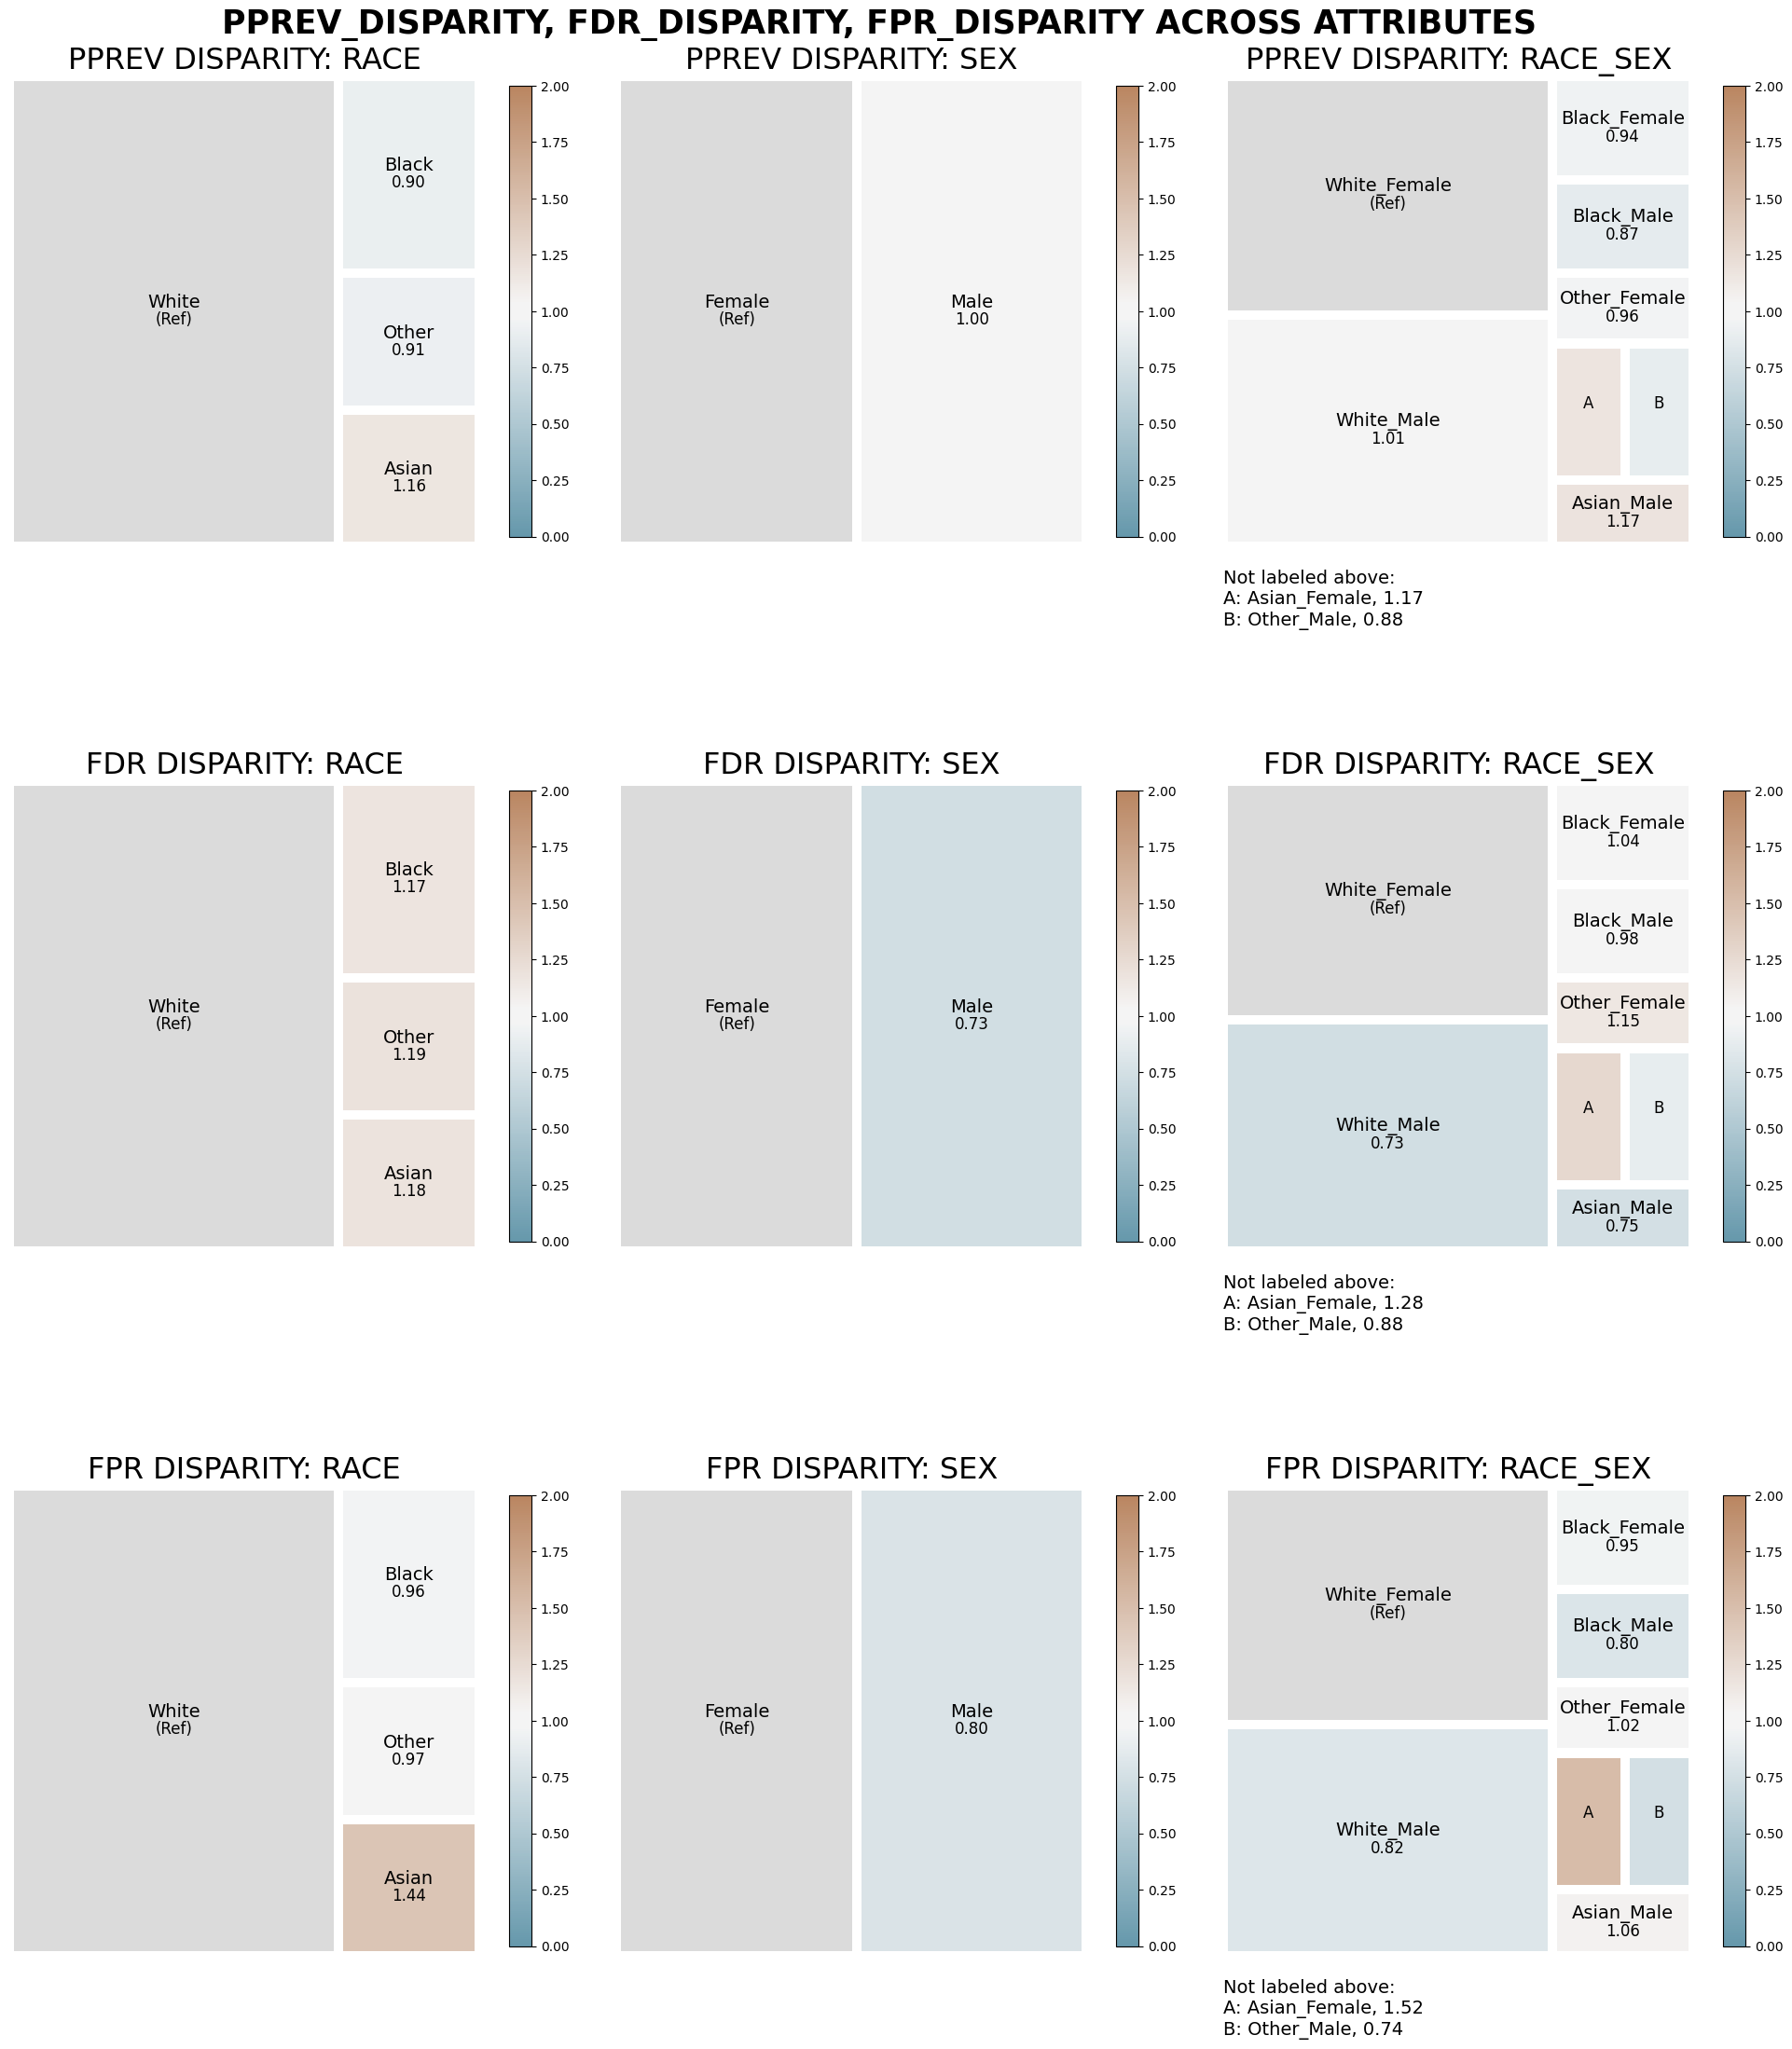

In [ ]:
#@title
majority_bdf = b.get_disparity_major_group(xtab, original_df=pred_data, mask_significance=True)
j = aqp.plot_disparity_all(majority_bdf, metrics=['pprev_disparity','fdr_disparity','fpr_disparity'], significance_alpha=0.05)

We can also apply statistical testing to see if disparities are significantly different from each other.

Those mosaics colored in green are those that have *Parity* between metrics at an $\alpha = 0.05$ significance level, and red indicates they have *disparity*.

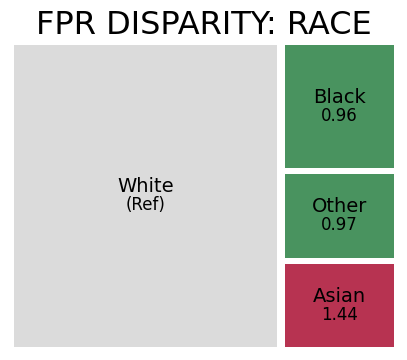

In [ ]:
#@title
f = Fairness()
fdf = f.get_group_value_fairness(bdf)
parity_detrminations = f.list_parities(fdf)
fdf[['attribute_name', 'attribute_value'] + absolute_metrics + calculated_disparities + parity_detrminations].style
m = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='race')

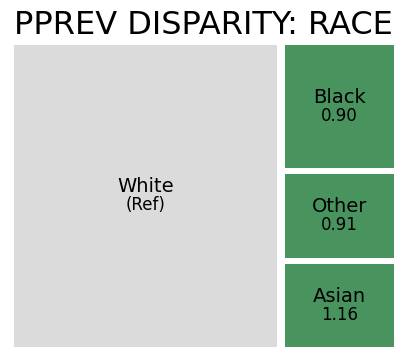

In [ ]:
#@title
m = aqp.plot_fairness_disparity(fdf, group_metric='pprev', attribute_name='race')

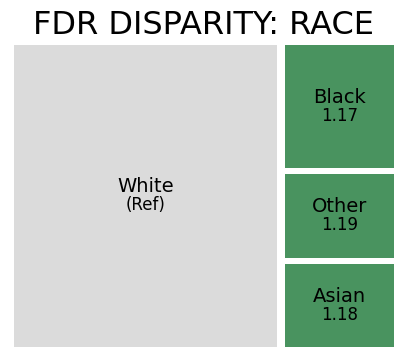

In [ ]:
#@title
m = aqp.plot_fairness_disparity(fdf, group_metric='fdr', attribute_name='race')

For this model, it seems like our biggest issue is a FPR disparity for Asain folks as compared to White folks.

If we took this tutorial one step further an applied bias mitigation, this would be an appropiate target.

# Statistical disparity across race and sex intersectionally.

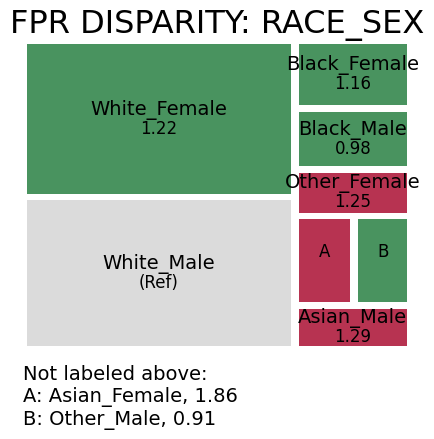

In [ ]:
#@title
m = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='race_sex')

Consider the following scenario:

Suppose a certain country in Europe is building a model to predict the risk that a criminal is going to recidivate, similiar to the prediction made by the COMPAS model discussed in class.  However, in contrast to COMPAS, the goal is not to use these scores to determine whether or not an individual is allowed to be free; instead, almost all individuals with a high risk score will be admitted into a special program that has three components:  (1) the individuals recieve one-on-one counseling, (2) the individuals will recieve a monthly stipend, and (3) the individuals are set up with housing.  The program is a benefit to the individuals and is aimed at reducing recividism.

Think about the confusion matrix for the model.  How would you define the positive and negative class?

Suppose the country is trying to decide on the proper fairness metric to use for their machine learning model, and cares about the protected attribute race.  In terms of representation, they would either accept a model that has equal nominal representation of different races, or equal proportional representation in the special program.  They are also concerned about errors made by the model, and want to make sure that predictive equity among groups is acheieved for people with need.

Review the Aequitas guidelines for fairness metrics, and think about them in the context of this problem:  http://www.datasciencepublicpolicy.org/projects/aequitas/.


**Question:** Which of the following is NOT a good choice for a fairness metric for the model?

> a) False Negative Rate Parity \
> b) Equal Selection Parity \
> c) Demographic Parity \
> d) False Positive Rate Parity
